# Question 1: 

ist fachgerechte sondermüll entsorgung in zürich zu teuer, müsste die stadt zürich einen billigen entsorgungsdienst anbieten? korrelieren die anzahl illegal entsorgten abfälle mit dem steuerbaren Einkommen der Bevölkerung


Import libraries

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import datetime as dt
import numpy as np
from scipy import stats

import import_clean_data

### Access and load data via API (züri wie neu, neighbourhoods, income)

In [2]:
zwn_gdf_raw = import_clean_data.import_zwn_data()
neighbourhoods_gdf_raw = import_clean_data.import_neighbourhood_data()
population_df_raw = import_clean_data.import_population_data()
income_df_raw = import_clean_data.import_income_data()


Data züri wie neu loaded sugessfull
Data züri wie neu loaded sugessfull
Data Population loaded sugessfull
Data Income loaded sugessfull


## clean and filter the data

filter income for the newest year and create a mean for the 3 steuertarife

In [3]:
## filter income for the newest year

# display the current year
current_year = int(dt.date.today().year)

#filter dataframe for the newest year (always current year minus 3)
income_df = income_df_raw[income_df_raw["StichtagDatJahr"] == str(current_year -3)].copy()


In [4]:
## create a mean for the 3 steuer tarife

#clean the data (drop na, convert to float)
income_df.dropna(subset=["SteuerEinkommen_p50"])
income_df["SteuerEinkommen_p50"] = income_df["SteuerEinkommen_p50"].astype(float)

#group by neigbourhoods and compute the mean income (of the 3 steuertarife) for each income
steuertarife_grouped_by_neighbourhoods = income_df.groupby("QuarLang", as_index=False)

income_df = steuertarife_grouped_by_neighbourhoods[["SteuerEinkommen_p50"]].mean()
income_df = income_df.rename(columns={"SteuerEinkommen_p50": "mean_income", "QuarLang": "qname"})

filter and clean züri wie neu data

In [5]:
# Sort the züri wie neu data for waste and filter the columns

zwn_waste_gdf = zwn_gdf_raw[zwn_gdf_raw["service_name"]=="Abfall/Sammelstelle"].copy()
zwn_waste_gdf = zwn_waste_gdf[["service_request_id", "title", "geometry"]]

clean neighbourhood data

In [6]:
#clean neighbourhoods file

neighbourhoods_gdf = neighbourhoods_gdf_raw[["qname", "qnr", "geometry"]]

clean population data

In [35]:
## filter population for the newest year

# display the current year
current_year = int(dt.date.today().year)

#filter dataframe for the newest year (always current year minus 3)
population_df = population_df_raw[population_df_raw["StichtagDatJahr"] == str(current_year-1)].copy()

#clean the population data (convert to int, keep important columns)

population_df= population_df.drop(columns=["StichtagDatJahr", "QuarSort", "_id"])
population_df["AnzBestWir"] = population_df["AnzBestWir"].astype(int)

population_df = population_df.rename(columns={"AnzBestWir": "population", "QuarLang": "qname"})

population_df.info()

<class 'pandas.DataFrame'>
Index: 34 entries, 0 to 2729
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   qname       34 non-null     str  
 1   population  34 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


## join and merge data together

In [7]:

#join the trash points to the neighbourhoods

waste_with_neighbourhoods_df = gpd.sjoin(zwn_waste_gdf, 
                                          neighbourhoods_gdf,
                                          how="inner",
                                          predicate="within")

neighbourhoods_with_waste_df = waste_with_neighbourhoods_df[["qname"]].value_counts()

neighbourhoods_with_waste_df.head(3)

qname      
Langstrasse    3873
Sihlfeld       3161
Hard           1636
Name: count, dtype: int64

In [32]:
# merge the income to the neighbourhoods

neighbourhoods_with_waste_income_df = pd.merge(left=neighbourhoods_with_waste_df, 
                                        right=income_df,
                                        left_on="qname",
                                        right_on="qname")
neighbourhoods_with_waste_income_df = neighbourhoods_with_waste_income_df.sort_values(by="mean_income", ascending=True)
neighbourhoods_with_waste_income_df = neighbourhoods_with_waste_income_df.set_index("qname")

neighbourhoods_with_waste_income_df.info()

<class 'pandas.DataFrame'>
Index: 34 entries, Hirzenbach to Fluntern
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   count        34 non-null     int64  
 1   mean_income  34 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [36]:
# merge the population to the neighbourhoods

neighbourhoods_with_waste_income_pop_df = pd.merge(left=neighbourhoods_with_waste_income_df, 
                                        right=population_df,
                                        left_index=True,
                                        right_on="qname")
neighbourhoods_with_waste_income_pop_df.info()


<class 'pandas.DataFrame'>
Index: 34 entries, 2729 to 1427
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   count        34 non-null     int64  
 1   mean_income  34 non-null     float64
 2   qname        34 non-null     str    
 3   population   34 non-null     int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 1.6 KB


In [37]:

# normalize the waste per person

neighbourhoods_with_waste_income_pop_gdf = pd.merge(left=neighbourhoods_gdf, 
                                        right=neighbourhoods_with_waste_income_pop_df,
                                        left_on="qname",
                                        right_on="qname")


neighbourhoods_with_waste_income_pop_gdf["waste_density"] = neighbourhoods_with_waste_income_pop_gdf["count"]/neighbourhoods_with_waste_income_pop_gdf["population"]

neighbourhoods_with_waste_income_pop_gdf = neighbourhoods_with_waste_income_pop_gdf.sort_values(by="mean_income", ascending=True)
neighbourhoods_with_waste_income_pop_gdf = neighbourhoods_with_waste_income_pop_gdf.set_index("qname")

neighbourhoods_with_waste_income_pop_gdf.info(
    
)


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 34 entries, Hirzenbach to Fluntern
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   qnr            34 non-null     int32   
 1   geometry       34 non-null     geometry
 2   count          34 non-null     int64   
 3   mean_income    34 non-null     float64 
 4   population     34 non-null     int64   
 5   waste_density  34 non-null     float64 
dtypes: float64(2), geometry(1), int32(1), int64(2)
memory usage: 2.0 KB


## Plot Data


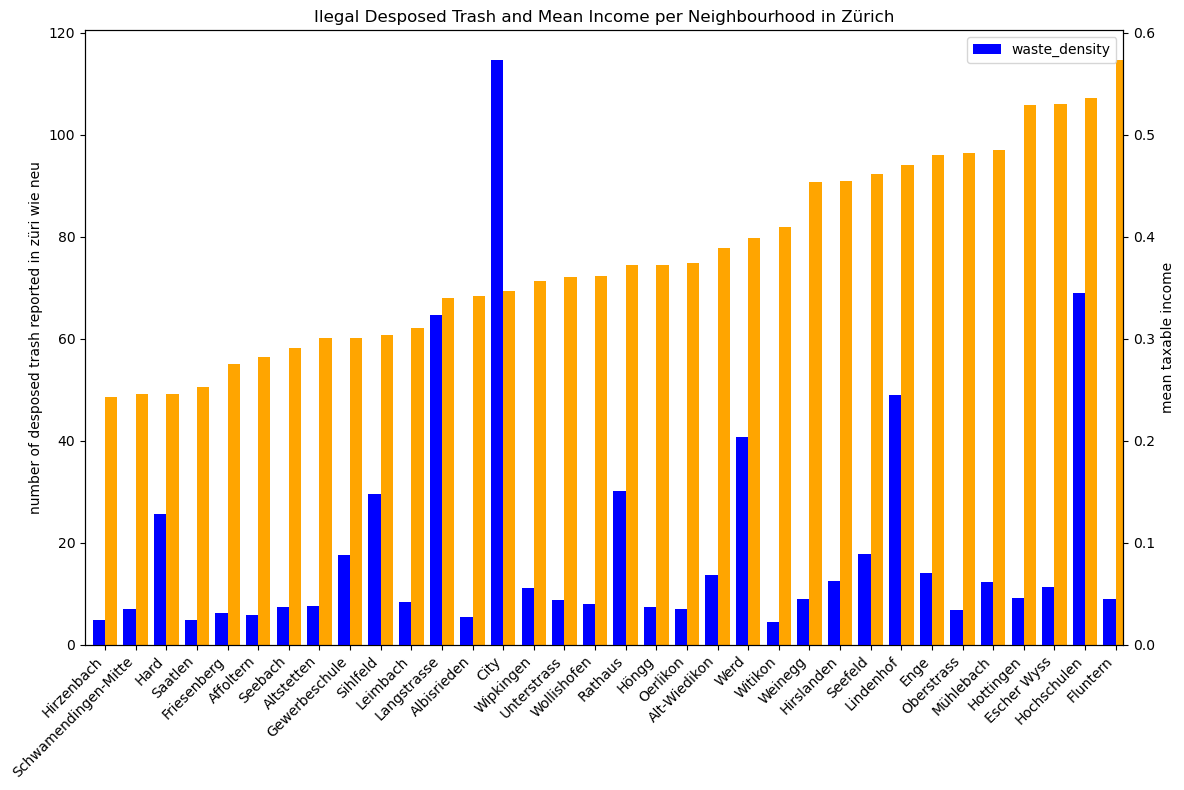

In [38]:
fig, ax1 = plt.subplots(figsize= (12,8))
ax2 = ax1.twinx()

neighbourhoods_with_waste_income_pop_gdf["mean_income"].plot(kind="bar", ax=ax1, width= 0.4, position=0, color= "orange",
                               title="Ilegal Desposed Trash and Mean Income per Neighbourhood in Zürich",
                               ylabel="number of desposed trash reported in züri wie neu",
                               xlabel="")
neighbourhoods_with_waste_income_pop_gdf["waste_density"].plot(kind="bar", ax=ax2, width= 0.4, position=1, color= "blue",
                         ylabel="mean taxable income"
                         )
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, horizontalalignment="right")
plt.tight_layout()
plt.legend()


plt.show()

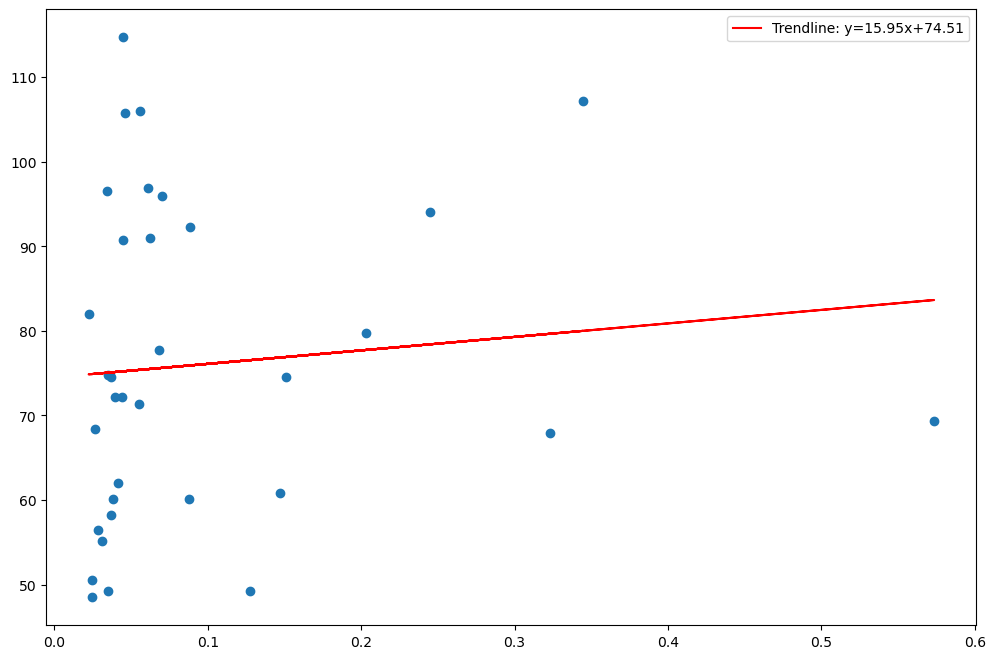

In [39]:
fig, ax3 = plt.subplots(figsize= (12,8))

ax3.scatter(neighbourhoods_with_waste_income_pop_gdf["waste_density"], neighbourhoods_with_waste_income_pop_gdf["mean_income"])
m, b = np.polyfit(neighbourhoods_with_waste_income_pop_gdf["waste_density"], neighbourhoods_with_waste_income_pop_gdf["mean_income"], 1)
x= neighbourhoods_with_waste_income_pop_gdf["waste_density"]
y= neighbourhoods_with_waste_income_pop_gdf["mean_income"]
plt.plot(x, m*x + b, color='red', linestyle='-', label=f'Trendline: y={m:.2f}x+{b:.2f}')
plt.legend()
plt.show()


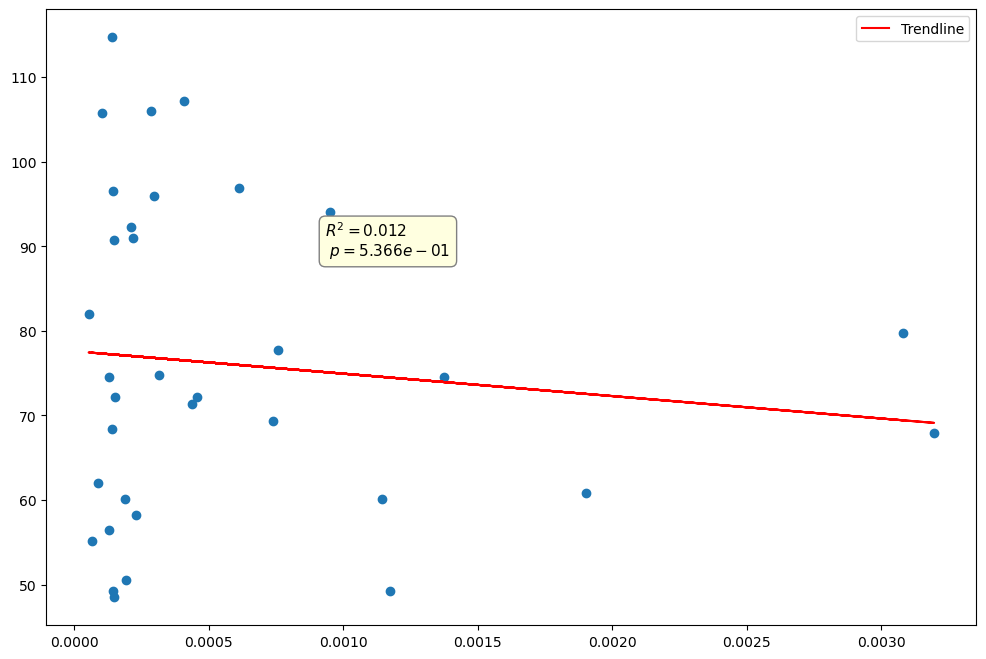

In [12]:
fig, ax3 = plt.subplots(figsize= (12,8))

x= neighbourhoods_with_waste_income_gdf["waste_density"]
y= neighbourhoods_with_waste_income_gdf["mean_income"]

ax3.scatter(x,y)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2
y_line = slope * x + intercept
ax3.plot(x, y_line, color='red',label='Trendline')


ax3.annotate(
    f'$R^2 = {r_squared:.3f}$  \n $p = {p_value:.3e}$',
    xy=(0.3, 0.6), xycoords='axes fraction', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray')
    
)


plt.legend()
plt.show()